In [ ]:
pip install yfinance pandas numpy matplotlib


/tmp/ipykernel_207/430721848.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks, start=start_date)["Close"]
[*********************100%***********************]  10 of 10 completed


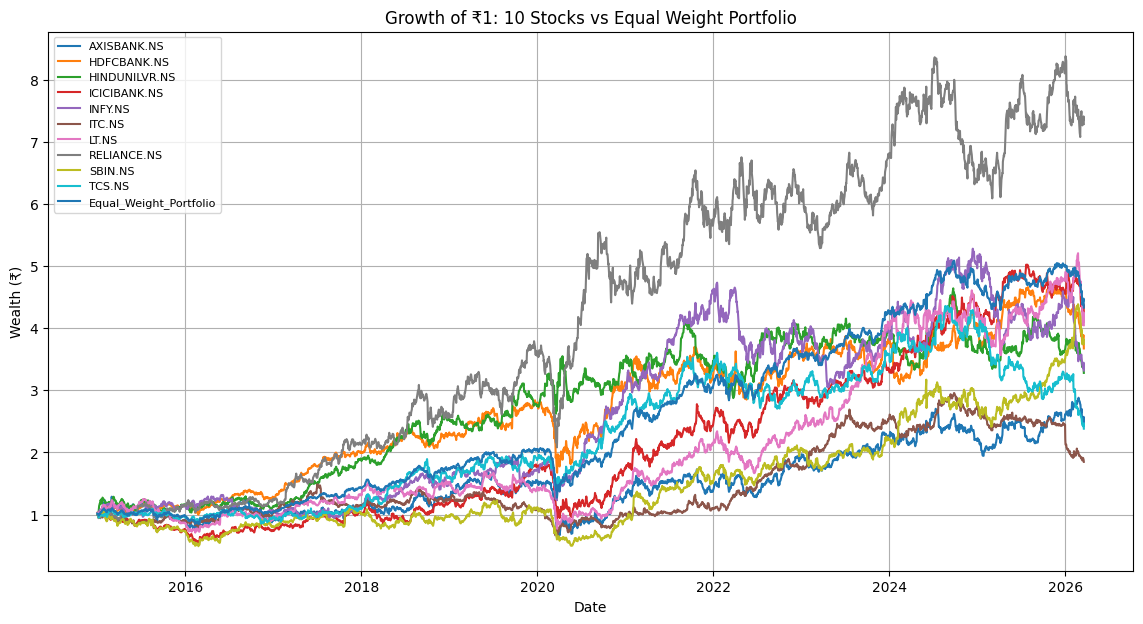


Final Wealth of ₹1 Investment:
Ticker
RELIANCE.NS               7.288429
Equal_Weight_Portfolio    4.332376
ICICIBANK.NS              4.251696
LT.NS                     4.048526
SBIN.NS                   3.747670
HDFCBANK.NS               3.674356
INFY.NS                   3.319458
HINDUNILVR.NS             3.280784
AXISBANK.NS               2.478628
TCS.NS                    2.382494
ITC.NS                    1.848362
Name: 2026-03-19 00:00:00, dtype: float64


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Select Stocks
# ----------------------------
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "HINDUNILVR.NS",
    "SBIN.NS",
    "ITC.NS",
    "LT.NS",
    "AXISBANK.NS"
]

start_date = "2015-01-01"

# ----------------------------
# Step 2: Download Price Data
# ----------------------------
prices = yf.download(stocks, start=start_date)["Close"]
prices = prices.dropna()

# ----------------------------
# Step 3: Calculate Returns
# ----------------------------
returns = prices.pct_change().dropna()

# ----------------------------
# Step 4: Equal Weight Portfolio
# ----------------------------
n_assets = len(stocks)
weights = np.ones(n_assets) / n_assets

portfolio_returns = returns.dot(weights)

# ----------------------------
# Step 5: Compute ₹1 Growth
# ----------------------------

# Individual stock growth
stock_wealth = (1 + returns).cumprod()

# Equal weight portfolio growth
portfolio_wealth = (1 + portfolio_returns).cumprod()

# Add portfolio to dataframe
stock_wealth["Equal_Weight_Portfolio"] = portfolio_wealth

# ----------------------------
# Step 6: Plot All 11 Lines
# ----------------------------
plt.figure(figsize=(14,7))

for column in stock_wealth.columns:
    plt.plot(stock_wealth.index, stock_wealth[column], label=column)

plt.title("Growth of ₹1: 10 Stocks vs Equal Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Wealth (₹)")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True)
plt.show()

# ----------------------------
# Step 7: Final Values (Total Return)
# ----------------------------
final_values = stock_wealth.iloc[-1].sort_values(ascending=False)

print("\nFinal Wealth of ₹1 Investment:")
print(final_values)

In [ ]:
#Markowitz Portfolio (PyPortfolioOpt)
# Markowitz assigns:
# Higher weight to stocks with high return
# Lower weight to stocks with high volatility
# Lower weight to highly correlated stocks
# So unlike Equal Weight:
# Equal Weight ignores risk & correlation
# Markowitz uses full covariance structure

!pip install PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 10.9 MB/s eta 0:00:00


[*********************100%***********************]  10 of 10 completed



Markowitz Weights:
Ticker
HDFCBANK.NS      0.00000
HINDUNILVR.NS    0.00000
ICICIBANK.NS     0.00000
INFY.NS          0.00000
ITC.NS           0.00000
KOTAKBANK.NS     0.00000
LT.NS            0.20116
RELIANCE.NS      0.39884
SBIN.NS          0.40000
TCS.NS           0.00000
dtype: float64


[*********************100%***********************]  1 of 1 completed


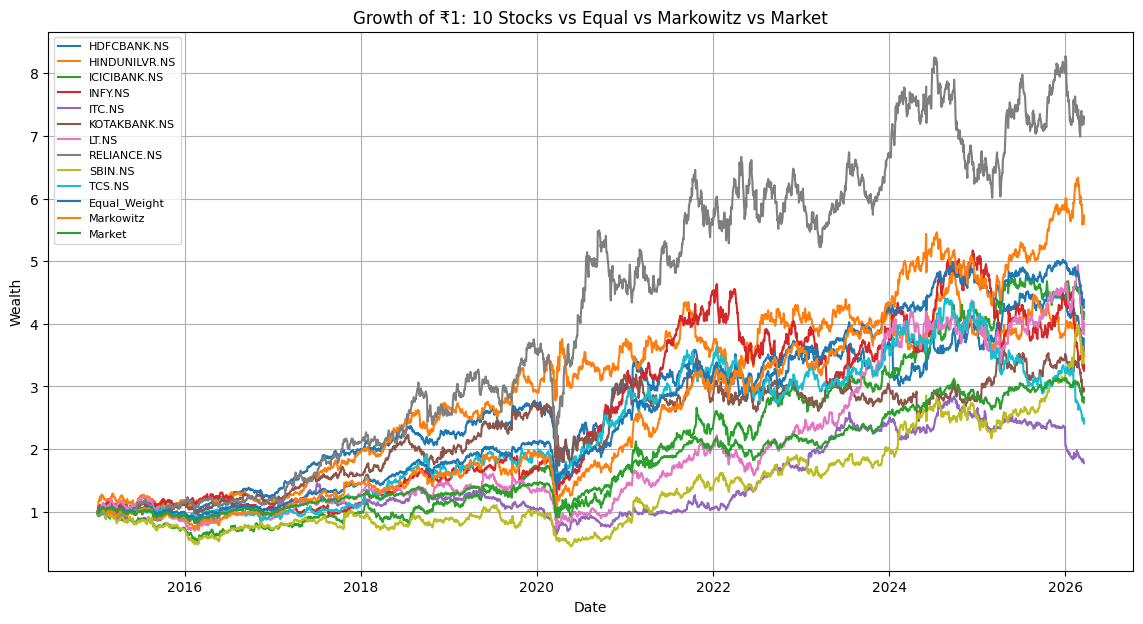


Performance Summary:
               Annual Return  Volatility  Sharpe Ratio
Equal_Weight        0.145744    0.163728      0.890159
RELIANCE.NS         0.216822    0.271000      0.800081
Markowitz           0.183946    0.230822      0.796916
Market              0.105344    0.162502      0.648260
HDFCBANK.NS         0.140584    0.221615      0.634358
HINDUNILVR.NS       0.138205    0.222780      0.620365
LT.NS               0.158766    0.267973      0.592468
ICICIBANK.NS        0.174192    0.303490      0.573963
INFY.NS             0.142895    0.265051      0.539125
KOTAKBANK.NS        0.131831    0.260441      0.506185
SBIN.NS             0.163828    0.326586      0.501638
TCS.NS              0.107526    0.233798      0.459911
ITC.NS              0.082789    0.245843      0.336754

Final Wealth (₹1 Investment):
RELIANCE.NS      7.194155
Markowitz        5.593595
Equal_Weight     4.255447
ICICIBANK.NS     4.071122
LT.NS            3.838769
HDFCBANK.NS      3.561615
HINDUNILVR.NS    3.46

'\n“Although Markowitz produced higher upper quantile returns, its higher volatility reduced geometric growth,\n resulting in lower cumulative wealth compared to the Equal-weight portfolio.”\n\n In-Sample Optimization\n\nYou are:\n\nLooking at the full history\n\nLearning optimal weights\n\nTesting on the same history\n\nThis creates:\n\n⚠️ Look-ahead bias\n\nBecause in reality:\n\nIn 2015 you did NOT know 2026 returns.\n\nBut your model is using that future information.\n'

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models, EfficientFrontier

# -----------------------------
# Step 1: Define Stocks
# -----------------------------
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "HINDUNILVR.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "SBIN.NS",
    "ITC.NS"
]

start_date = "2015-01-01"

# -----------------------------
# Step 2: Download Data
# -----------------------------
prices = yf.download(stocks, start=start_date, auto_adjust=True)["Close"]
prices = prices.dropna()

# -----------------------------
# Step 3: Compute Daily Returns
# -----------------------------
returns = prices.pct_change().dropna()

# -----------------------------
# Step 4: Equal Weight Portfolio
# -----------------------------
n_assets = len(stocks)
equal_weights = np.ones(n_assets) / n_assets
equal_returns = returns.dot(equal_weights)

# -----------------------------
# Step 5: Markowitz Portfolio
# -----------------------------
mu = expected_returns.ema_historical_return(prices)
S = risk_models.sample_cov(prices)

ef = EfficientFrontier(mu, S, weight_bounds=(0, 0.4))
ef.max_sharpe()
markowitz_weights = ef.clean_weights()

weights_series = pd.Series(markowitz_weights)
weights_series = weights_series.reindex(prices.columns)

markowitz_returns = returns.dot(weights_series.values)

print("\nMarkowitz Weights:")
print(weights_series)

# -----------------------------
# Step 6: Market (NIFTY)
# -----------------------------
nifty = yf.download("^NSEI", start=start_date, auto_adjust=True)["Close"]
nifty_returns = nifty.pct_change().dropna()

# -----------------------------
# Step 7: Combine Everything
# -----------------------------

# Individual stocks
all_returns = returns.copy()

# Add portfolios
all_returns["Equal_Weight"] = equal_returns
all_returns["Markowitz"] = markowitz_returns

# Align with market
combined = pd.concat([all_returns, nifty_returns], axis=1, join="inner")
combined.rename(columns={"Close": "Market"}, inplace=True)
combined.columns = list(all_returns.columns) + ["Market"]

# -----------------------------
# Step 8: Wealth (₹1 Growth)
# -----------------------------
wealth = (1 + combined).cumprod()

# -----------------------------
# Step 9: Plot All
# -----------------------------
plt.figure(figsize=(14,7))

for column in wealth.columns:
    plt.plot(wealth.index, wealth[column], label=column)

plt.legend(loc="upper left", fontsize=8)
plt.title("Growth of ₹1: 10 Stocks vs Equal vs Markowitz vs Market")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.grid(True)
plt.show()

# -----------------------------
# Step 10: Performance Summary
# -----------------------------
annual_return = combined.mean() * 252
annual_vol = combined.std() * np.sqrt(252)
sharpe = annual_return / annual_vol

summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Volatility": annual_vol,
    "Sharpe Ratio": sharpe
}).sort_values(by="Sharpe Ratio", ascending=False)

print("\nPerformance Summary:")
print(summary)

# -----------------------------
# Step 11: Final Wealth Ranking
# -----------------------------
final_wealth = wealth.iloc[-1].sort_values(ascending=False)

print("\nFinal Wealth (₹1 Investment):")
print(final_wealth)

"""
“Although Markowitz produced higher upper quantile returns, its higher volatility reduced geometric growth,
 resulting in lower cumulative wealth compared to the Equal-weight portfolio.”

 In-Sample Optimization

You are:

Looking at the full history

Learning optimal weights

Testing on the same history

This creates:

⚠️ Look-ahead bias

Because in reality:

In 2015 you did NOT know 2026 returns.

But your model is using that future information.
"""

In [ ]:
#rolling window for defining dynamic weight
!pip install PyPortfolioOpt


[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed


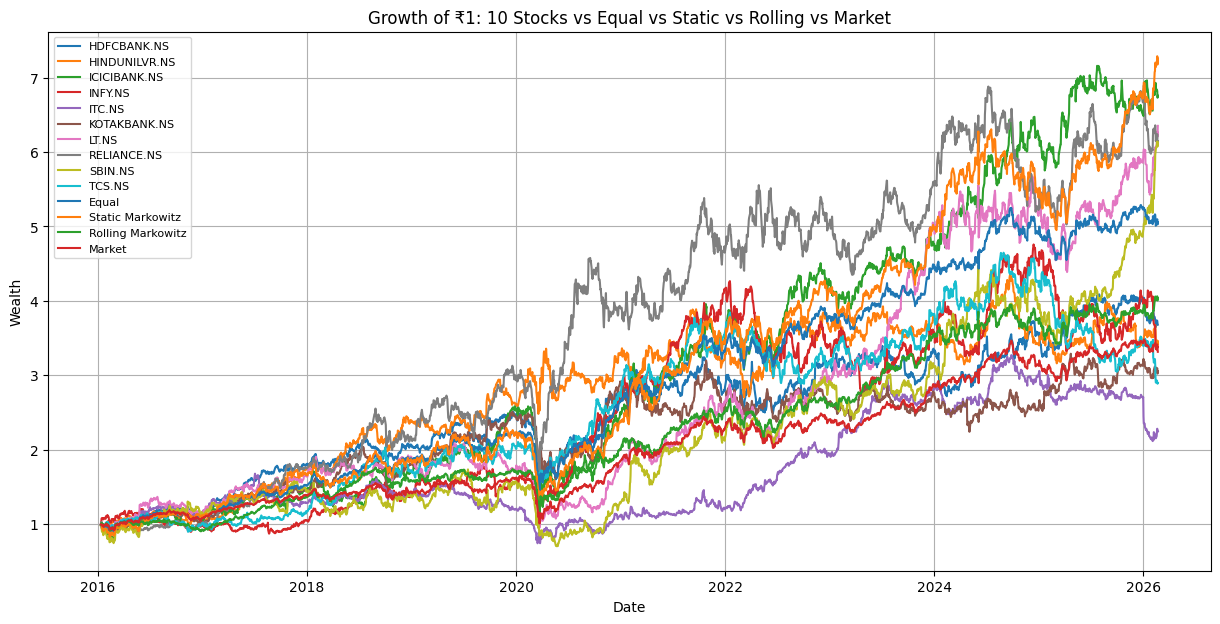


Performance Summary
                   Arithmetic Return  Geometric Return  Volatility    Sharpe
Equal                       0.177245          0.163807    0.163140  1.086457
Static Markowitz            0.226942          0.200308    0.230229  0.985724
Rolling Markowitz           0.157192          0.141042    0.179091  0.877720
Market                      0.136341          0.123128    0.161777  0.842773
LT.NS                       0.222060          0.186863    0.265147  0.837500
RELIANCE.NS                 0.219947          0.183522    0.270233  0.813915
ICICIBANK.NS                0.238700          0.193128    0.301973  0.790466
SBIN.NS                     0.236371          0.183214    0.327655  0.721404
HDFCBANK.NS                 0.156891          0.131686    0.224260  0.699594
HINDUNILVR.NS               0.149053          0.125249    0.218867  0.681022
INFY.NS                     0.156308          0.121134    0.264464  0.591037
TCS.NS                      0.135391          0.107441 

'\nour task is to maximize sharpe ratio which is depened on mu,cov matrix,and weigth which we have find\nso we minimize minus of sharpe ratio(Loss finction) and we are aplying GD on weigth.\n'

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models, EfficientFrontier

# ---------------- PARAMETERS ----------------
stocks = [
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS",
    "ICICIBANK.NS","HINDUNILVR.NS","KOTAKBANK.NS",
    "LT.NS","SBIN.NS","ITC.NS"
]

start_date = "2015-01-01"
window = 252          # 1 year training
rebalance_freq = 21   # monthly rebalance

# ---------------- DOWNLOAD DATA ----------------
prices = yf.download(stocks, start=start_date, auto_adjust=True)["Close"]
prices = prices.dropna()

returns = prices.pct_change().dropna()

# ==========================================================
# 1️⃣ EQUAL WEIGHT PORTFOLIO
# ==========================================================
equal_weights = np.ones(len(stocks)) / len(stocks)
equal_returns = returns.dot(equal_weights)

# ==========================================================
# 2️⃣ STATIC MARKOWITZ (In-sample)
# ==========================================================
mu_static = expected_returns.ema_historical_return(prices)
S_static = risk_models.sample_cov(prices)

ef_static = EfficientFrontier(mu_static, S_static, weight_bounds=(0,0.4))
ef_static.max_sharpe()
static_weights = pd.Series(ef_static.clean_weights())
static_weights = static_weights.reindex(prices.columns)

static_markowitz_returns = returns.dot(static_weights.values)

# ==========================================================
# 3️⃣ ROLLING MARKOWITZ (Out-of-sample)
# ==========================================================
rolling_portfolio_returns = []
rolling_weights_list = []   # 🔥 NEW: store weights

for start in range(window, len(returns)-rebalance_freq, rebalance_freq):

    train_prices = prices.iloc[start-window:start]

    # 1️⃣ Estimate parameters
    mu = expected_returns.ema_historical_return(train_prices)
    S = risk_models.sample_cov(train_prices)

    # 2️⃣ Optimize
    ef = EfficientFrontier(mu, S, weight_bounds=(0,0.4))
    ef.max_sharpe()
    weights = pd.Series(ef.clean_weights())
    weights = weights.reindex(prices.columns)

    weights_array = weights.values

    # 3️⃣ Apply weights to next period
    test_returns = returns.iloc[start:start+rebalance_freq]
    portfolio_period = test_returns.dot(weights_array)

    rolling_portfolio_returns.append(portfolio_period)

    # 4️⃣ 🔥 Store weights repeated for holding period
    repeat_block = np.tile(weights_array, (len(test_returns), 1))
    rolling_weights_list.append(repeat_block)

# ===============================
# Combine returns
# ===============================

rolling_markowitz_returns = pd.concat(rolling_portfolio_returns)

# ===============================
# Combine weights
# ===============================

rolling_weights_np = np.vstack(rolling_weights_list)

rolling_weights_df = pd.DataFrame(
    rolling_weights_np,
    index=rolling_markowitz_returns.index,
    columns=prices.columns
)

# ==========================================================
# 4️⃣ MARKET (NIFTY)
# ==========================================================
nifty = yf.download("^NSEI", start=start_date, auto_adjust=True)["Close"]
market_returns = nifty.pct_change().dropna()

# ==========================================================
# 5️⃣ COMBINE EVERYTHING
# ==========================================================
all_returns = returns.copy()
all_returns["Equal"] = equal_returns
all_returns["Static Markowitz"] = static_markowitz_returns

combined = pd.concat(
    [all_returns, rolling_markowitz_returns, market_returns],
    axis=1,
    join="inner"
)

combined.rename(columns={0: "Rolling Markowitz", "Close": "Market"}, inplace=True)

# Ensure correct naming
combined.columns = list(all_returns.columns) + ["Rolling Markowitz", "Market"]

# ==========================================================
# 6️⃣ WEALTH (₹1 Growth)
# ==========================================================
wealth = (1 + combined).cumprod()

# ==========================================================
# 7️⃣ PLOT EVERYTHING
# ==========================================================
plt.figure(figsize=(15,7))

for col in wealth.columns:
    plt.plot(wealth.index, wealth[col], label=col)

plt.legend(loc="upper left", fontsize=8)
plt.title("Growth of ₹1: 10 Stocks vs Equal vs Static vs Rolling vs Market")
plt.ylabel("Wealth")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# ==========================================================
# 8️⃣ PERFORMANCE SUMMARY
# ==========================================================
annual_return = combined.mean() * 252
annual_vol = combined.std() * np.sqrt(252)
sharpe = annual_return / annual_vol
geo = np.log(1 + combined).mean() * 252

summary = pd.DataFrame({
    "Arithmetic Return": annual_return,
    "Geometric Return": geo,
    "Volatility": annual_vol,
    "Sharpe": sharpe
}).sort_values(by="Sharpe", ascending=False)

print("\nPerformance Summary")
print(summary)

# ==========================================================
# 9️⃣ FINAL WEALTH RANKING
# ==========================================================
print("\nFinal Wealth Ranking (₹1 Investment):")
print(wealth.iloc[-1].sort_values(ascending=False))


"""
our task is to maximize sharpe ratio which is depened on mu,cov matrix,and weigth which we have find
so we minimize minus of sharpe ratio(Loss finction) and we are aplying GD on weigth.
"""

In [ ]:
"""
ML based implementatiom.
"""


import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
stocks = [
    "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS",
    "RELIANCE.NS","TCS.NS","INFY.NS",
    "HINDUNILVR.NS","ITC.NS","LT.NS","KOTAKBANK.NS"
]

start = "2005-01-01"

data = yf.download(stocks, start=start, auto_adjust=True)
prices = data["Close"].dropna()

returns = prices.pct_change()

# Shift returns backward (so today's features predict tomorrow's return)
returns = returns.shift(-1)

returns = returns.dropna()
prices = prices.loc[returns.index]

[*********************100%***********************]  10 of 10 completed


In [ ]:
mom_5  = prices.pct_change(5)
mom_20 = prices.pct_change(20)
mom_60 = prices.pct_change(60)

vol_20 = prices.pct_change().rolling(20).std()

"""
These measure how far price is from moving average.
"""
ma_20 = prices / prices.rolling(20).mean()
ma_50 = prices / prices.rolling(50).mean()

# Add RSI and mean reversion signal
def compute_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = -delta.clip(upper=0).rolling(window).mean()
    rs = gain / (loss + 1e-8)
    return 1 - (1 / (1 + rs))

rsi_14 = compute_rsi(prices)

# Mean reversion
rev_5  = -prices.pct_change(5)   # contrarian signal
features = pd.concat({
    "mom5": mom_5,
    "mom20": mom_20,
    "mom60": mom_60,
    "vol20": vol_20,
    "ma20": ma_20,
    "ma50": ma_50,
    "rsi14": rsi_14,        # NEW
    "rev5":  rev_5          # NEW

}, axis=1)

features = features.dropna()

# Align returns to features
returns = returns.loc[features.index]

In [ ]:
train_end = "2020-12-31"

X_train = features.loc[:train_end]
R_train = returns.loc[:train_end]

X_test = features.loc["2021-01-01":]
R_test = returns.loc["2021-01-01":]

In [ ]:
def prepare_data(X, R):

    X_list, R_list, dates = [], [], []

    for date in X.index:
        # Corrected: Unstack to get (stocks, features) DataFrame
        X_day = X.loc[date].unstack(level=0)   # (stocks, features)
        R_day = R.loc[date]

        if X_day.isnull().values.any():
            continue

        # Cross-sectional normalization (per day)
        X_day = (X_day - X_day.mean()) / X_day.std()

        X_list.append(X_day.values)
        R_list.append(R_day.values)
        dates.append(date)

    X_np = np.array(X_list)
    R_np = np.array(R_list)

    return torch.tensor(X_np, dtype=torch.float32), \
           torch.tensor(R_np, dtype=torch.float32), \
           dates

X_train_t, R_train_t, train_dates = prepare_data(X_train, R_train)
X_test_t, R_test_t, test_dates = prepare_data(X_test, R_test)

In [ ]:
# class SPTModel(nn.Module):
#     def __init__(self, n_features):
#         super().__init__()
#         self.theta = nn.Parameter(torch.randn(n_features) * 0.01)

#     def forward(self, X):
#         z = torch.matmul(X, self.theta)  # (T, N)
#         w = torch.softmax(z, dim=1)
#         return w

class SPTModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, X):
        T, N, F = X.shape
        X_flat = X.reshape(T*N, F)
        scores = self.net(X_flat)
        scores = scores.reshape(T, N)
        weights = torch.softmax(scores, dim=1)
        return weights

In [ ]:
def sharpe_loss(weights, returns, model, l2_lambda=1e-4, dd_lambda=0.1):

    Rp = torch.sum(weights * returns, dim=1)

    mean = torch.mean(Rp)
    std  = torch.std(Rp)
    sharpe = mean / (std + 1e-8)

    # Max drawdown penalty
    cumulative = torch.cumprod(1 + Rp, dim=0)
    rolling_max = torch.cummax(cumulative, dim=0).values
    drawdown = (rolling_max - cumulative) / (rolling_max + 1e-8)
    max_dd_penalty = torch.max(drawdown)

    l2_penalty = l2_lambda * sum(torch.sum(p**2) for p in model.parameters())

    return -sharpe + l2_penalty + dd_lambda * max_dd_penalty

In [ ]:
model = SPTModel(n_features=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=500, eta_min=1e-5
)

epochs = 1000

for epoch in range(epochs):
    optimizer.zero_grad()
    weights = model(X_train_t)
    loss = sharpe_loss(weights, R_train_t, model)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.014067
Epoch 100, Loss: -0.087312
Epoch 200, Loss: -0.131350
Epoch 300, Loss: -0.146127
Epoch 400, Loss: -0.164008
Epoch 500, Loss: -0.151434
Epoch 600, Loss: -0.144181
Epoch 700, Loss: -0.148729
Epoch 800, Loss: -0.159948
Epoch 900, Loss: -0.170270


In [ ]:
# ===============================
# Recompute ML weights (test set)
# ===============================

rebalance_freq = 21

with torch.no_grad():
    daily_weights = model(X_test_t).numpy()

monthly_weights = []

for i in range(0, len(daily_weights), rebalance_freq):
    # take first day weight of each month
    w = daily_weights[i]

    # repeat same weight for next 21 days
    repeat_block = np.tile(w, (rebalance_freq, 1))

    monthly_weights.append(repeat_block)

weights_np = np.vstack(monthly_weights)

# Trim in case it exceeds length
weights_np = weights_np[:len(daily_weights)]

# -------------------------------
# Apply position constraints
# -------------------------------

weights_np = np.clip(weights_np, 0.02, 0.20)
weights_np = weights_np / weights_np.sum(axis=1, keepdims=True)

# Convert to DataFrame (important for turnover calculation)
ml_weights_df = pd.DataFrame(
    weights_np,
    index=test_dates
)

# -------------------------------
# Compute raw ML returns
# -------------------------------

R_test_np = R_test_t.numpy()
ml_raw_returns = np.sum(weights_np * R_test_np, axis=1)

ml_raw_series = pd.Series(
    ml_raw_returns,
    index=test_dates
)

In [ ]:
def apply_real_world_controls(returns, weights,
                              cost=0.001,
                              target_vol=0.15,
                              dd_limit=-0.20,
                              exposure_cut=0.5):

    # Ensure returns is a pandas Series for alignment later
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns, index=weights.index if hasattr(weights, 'index') else None)

    # Ensure weights_np is a 2D numpy array (N, M) for consistent operations
    weights_np = weights.copy()
    if isinstance(weights_np, (pd.Series, pd.DataFrame)):
        weights_np = weights_np.values
    if weights_np.ndim == 1:
        weights_np = weights_np.reshape(-1, 1) # Reshape 1D array to (N, 1)

    num_days = weights_np.shape[0]

    # # ===============================
    # # 1️⃣ Transaction Cost
    # # ===============================

    # # Calculate daily turnover (difference between consecutive weights)
    # # This results in an array of shape (num_days - 1, num_assets)
    # weights_diff = np.abs(weights_np[1:] - weights_np[:-1])

    # # Sum across assets to get total turnover for each day (shape: num_days - 1,)
    # daily_turnover = np.sum(weights_diff, axis=1)

    # # Initialize full turnover array with 0 for the first day (no prior weights)
    # turnover_full = np.zeros(num_days)
    # turnover_full[1:] = daily_turnover

    # # Apply transaction cost
    # returns_after_cost = returns - cost * turnover_full
    # returns = returns_after_cost # Use returns_after_cost for subsequent steps

    # ===============================
    # 2️⃣ Volatility Targeting
    # ===============================

    rolling_vol = returns.rolling(20).std() * np.sqrt(252)
    scaling = target_vol / (rolling_vol + 1e-8)
    scaling = scaling.clip(upper=2.0)

    returns = returns * scaling
    returns = returns.dropna()

    # ===============================
    # 3️⃣ Drawdown Control
    # ===============================

    wealth = (1 + returns).cumprod()
    rolling_max = wealth.cummax()
    drawdown = (wealth - rolling_max) / rolling_max

    exposure = np.ones(len(returns))

    for i in range(len(drawdown)):
        if drawdown.iloc[i] < dd_limit:
            exposure[i] = exposure_cut

    returns = returns * exposure

    return returns

In [ ]:
n_assets = 10

equal_weights = pd.DataFrame(
    np.ones((len(combined), n_assets)) / n_assets,
    index=combined.index
)

equal_returns = combined["Equal"].values

equal_adjusted = apply_real_world_controls(
    equal_returns,
    equal_weights
)

# Use cleaned_weights from BCI-YHum1GjH as w_static
# Convert OrderedDict to a numpy array of its values
w_static = np.array(list(markowitz_weights.values()))

# Ensure w_static is a 1D array for tiling
if isinstance(w_static, pd.Series):
    w_static = w_static.values

# Create static_weights_matrix with correct shape (len(combined), n_assets)
static_weights_matrix = pd.DataFrame(
    np.tile(w_static, (len(combined), 1)), # Tile the 1D array across rows
    index=combined.index,
    columns=markowitz_weights.keys() # Use original stock names as columns
)

static_returns = combined["Static Markowitz"].values

static_adjusted = apply_real_world_controls(
    static_returns,
    static_weights_matrix
)

# For rolling_weights_df, we don't have it explicitly saved.
# As a placeholder, let's assume equal weights for the purpose of turnover calculation for rolling_adjusted.
# In a real scenario, these weights would need to be stored during the rolling optimization.
# Align returns with weights
rolling_returns_aligned = combined["Rolling Markowitz"].reindex(rolling_weights_df.index)

rolling_adjusted = apply_real_world_controls(
    rolling_returns_aligned,
    rolling_weights_df
)

market_weights = pd.DataFrame(
    np.ones((len(combined), 1)),
    index=combined.index,
    columns=["Market"]
)

market_adjusted = apply_real_world_controls(
    combined["Market"].values,
    market_weights
)

# For ML adjusted, ml_raw_series.index is shorter, ensure weights align
ml_weights_df_aligned = ml_weights_df.reindex(ml_raw_series.index).dropna()
ml_raw_series_aligned = ml_raw_series.reindex(ml_weights_df_aligned.index)

# Call apply_real_world_controls and directly assign the returned Series
ml_adjusted = apply_real_world_controls(
    ml_raw_series_aligned, # Pass the Series directly
    ml_weights_df_aligned
)


In [ ]:
annual_return = ml_adjusted.mean() * 252
annual_vol = ml_adjusted.std() * np.sqrt(252)
test_sharpe = annual_return / annual_vol

print("Test Sharpe (ML):", round(test_sharpe, 4))

Test Sharpe (ML): 1.0554


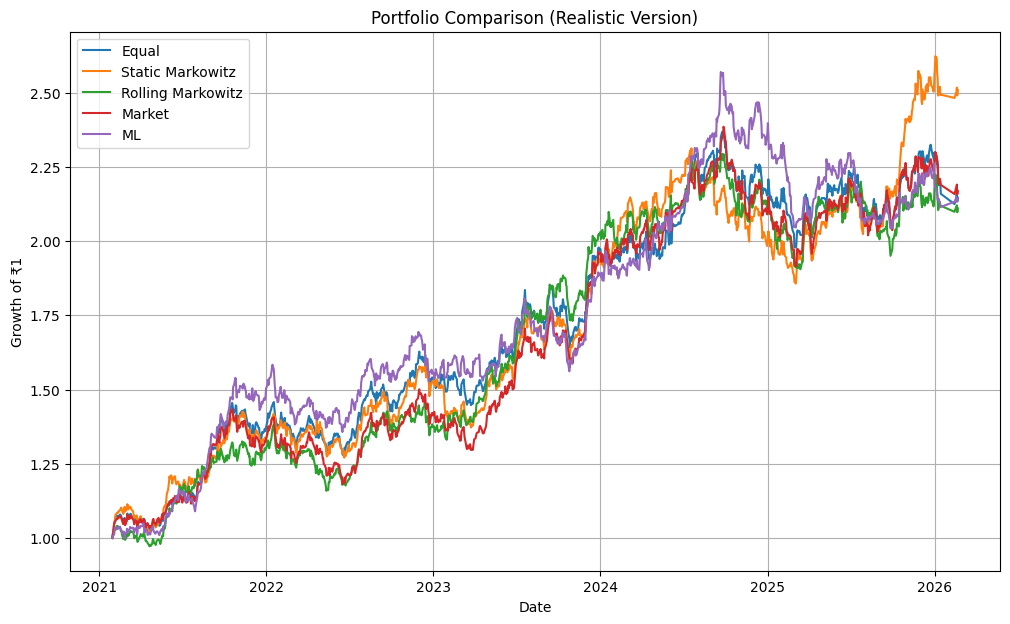

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1️⃣ Align all adjusted returns
# -------------------------------

comparison = pd.concat(
    [
        equal_adjusted,
        static_adjusted,
        rolling_adjusted,
        market_adjusted,
        ml_adjusted
    ],
    axis=1
)

comparison.columns = [
    "Equal",
    "Static Markowitz",
    "Rolling Markowitz",
    "Market",
    "ML"
]

# Drop NaNs (vol targeting creates initial NaNs)
comparison = comparison.dropna()

# -------------------------------
# 2️⃣ Convert to wealth
# -------------------------------

wealth = (1 + comparison).cumprod()

# Normalize to 1
wealth = wealth / wealth.iloc[0]

# -------------------------------
# 3️⃣ Plot
# -------------------------------

plt.figure(figsize=(12,7))

for col in wealth.columns:
    plt.plot(wealth.index, wealth[col], label=col)

plt.title("Portfolio Comparison (Realistic Version)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
annual_return = comparison.mean() * 252
annual_vol = comparison.std() * np.sqrt(252)
sharpe = annual_return / annual_vol
geo = np.log(1 + comparison).mean() * 252 # Geometric return calculation

syn_summary = pd.DataFrame({
    "Arithmetic Return": annual_return,
    "Geometric Return": geo,
    "Volatility": annual_vol,
    "Sharpe": sharpe
})

print("\nPerformance Summary")
print(syn_summary)

"Aplly early stoping tomorrow"


Performance Summary
                   Arithmetic Return  Geometric Return  Volatility    Sharpe
Equal                       0.165496          0.154189    0.150188  1.101929
Static Markowitz            0.198386          0.186804    0.151832  1.306610
Rolling Markowitz           0.160789          0.149394    0.150777  1.066404
Market                      0.167044          0.155652    0.150679  1.108611
ML                          0.173174          0.162182    0.148045  1.169741


'Aplly early stoping tomorrow'

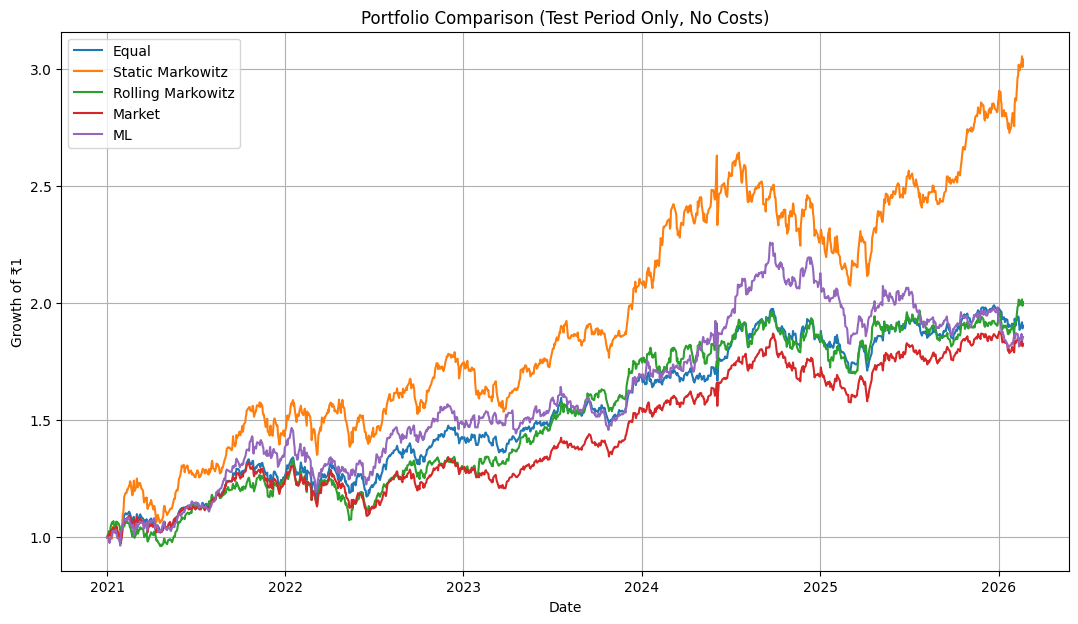


Performance Summary (Test Period Only)
                   Arithmetic Return  Geometric Return  Volatility    Sharpe
Static Markowitz            0.241342          0.222160    0.195140  1.236763
Equal                       0.138159          0.128568    0.138317  0.998857
Rolling Markowitz           0.153123          0.139710    0.163279  0.937802
Market                      0.129444          0.119698    0.139347  0.928936
ML                          0.135952          0.123774    0.155681  0.873269


In [ ]:
#without any trasaction cost and other limitations
# ===============================
# 1️⃣ Define Test Period
# ===============================

test_start = "2021-01-01"

equal_test = combined["Equal"].loc[test_start:]
static_test = combined["Static Markowitz"].loc[test_start:]
rolling_test = combined["Rolling Markowitz"].loc[test_start:]
market_test = combined["Market"].loc[test_start:]

# ML already test-period only
ml_test = ml_raw_series.copy()

# Align ML index with others
ml_test = ml_test.reindex(equal_test.index)

# ===============================
# 2️⃣ Combine All 5
# ===============================

comparison = pd.concat(
    [equal_test, static_test, rolling_test, market_test, ml_test],
    axis=1
)

comparison.columns = [
    "Equal",
    "Static Markowitz",
    "Rolling Markowitz",
    "Market",
    "ML"
]

comparison = comparison.dropna()

# ===============================
# 3️⃣ Convert to Wealth (₹1 Growth)
# ===============================

wealth = (1 + comparison).cumprod()
wealth = wealth / wealth.iloc[0]

# ===============================
# 4️⃣ Plot
# ===============================

plt.figure(figsize=(13,7))

for col in wealth.columns:
    plt.plot(wealth.index, wealth[col], label=col)

plt.title("Portfolio Comparison (Test Period Only, No Costs)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# 5️⃣ Performance Summary
# ===============================

annual_return = comparison.mean() * 252
annual_vol = comparison.std() * np.sqrt(252)
sharpe = annual_return / annual_vol
geo = np.log(1 + comparison).mean() * 252

summary = pd.DataFrame({
    "Arithmetic Return": annual_return,
    "Geometric Return": geo,
    "Volatility": annual_vol,
    "Sharpe": sharpe
}).sort_values(by="Sharpe", ascending=False)

print("\nPerformance Summary (Test Period Only)")
print(summary)

[*********************100%***********************]  10 of 10 completed


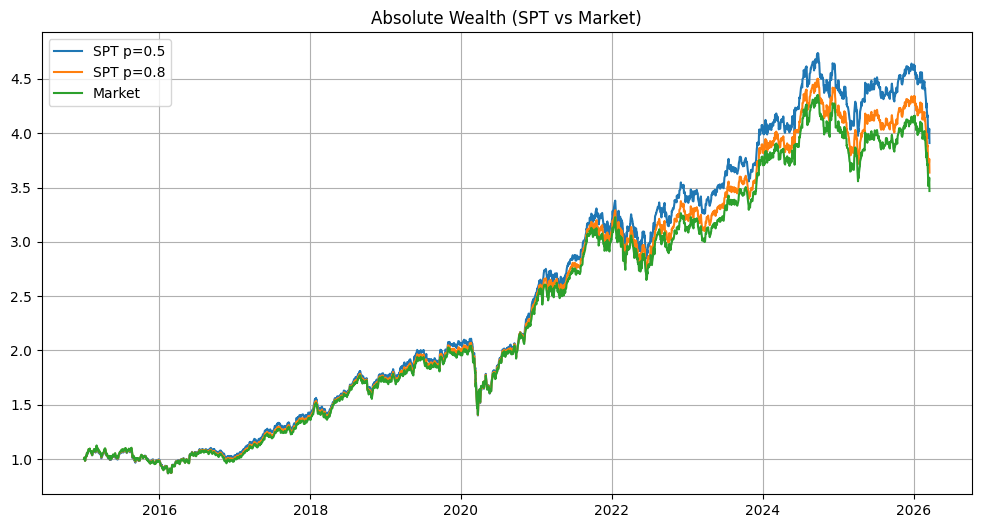

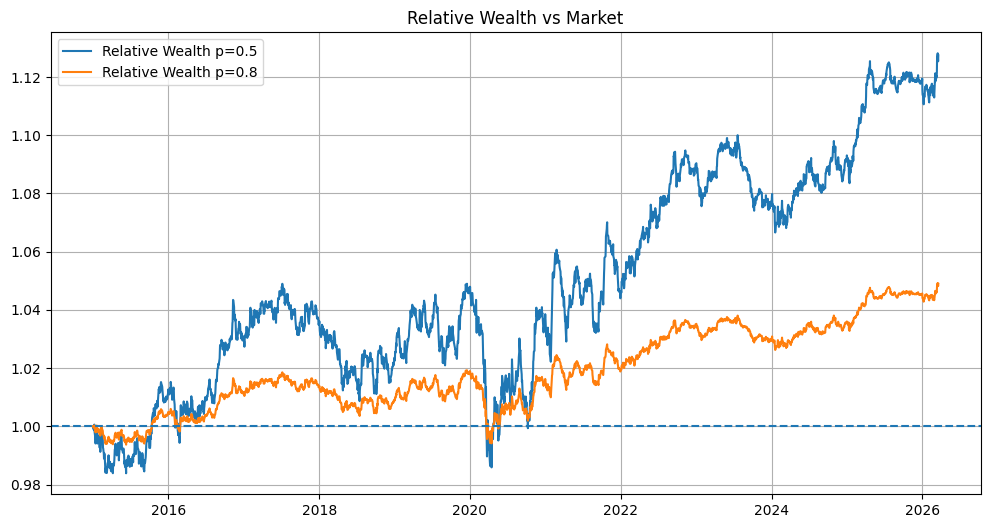


Performance Summary (SPT vs Market)
           Arithmetic Return  Geometric Return  Volatility    Sharpe
SPT p=0.5           0.136779          0.124043    0.159050  0.859976
SPT p=0.8           0.130074          0.117475    0.158294  0.821725
Market              0.125768          0.113127    0.158629  0.792846


In [ ]:
# ================================ SPT
# 1️⃣ Import Libraries
# ================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 2️⃣ Download Data
# ================================
stocks = [
    "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS",
    "RELIANCE.NS","TCS.NS","INFY.NS",
    "HINDUNILVR.NS","ITC.NS","LT.NS","KOTAKBANK.NS"
]

start = "2015-01-01"

data = yf.download(stocks, start=start, auto_adjust=True)

prices = data["Close"].dropna()

# ================================
# 3️⃣ Compute Returns (NO look-ahead)
# ================================
returns = prices.pct_change().dropna()

# ================================
# 4️⃣ Compute Market Weights (SPT Proxy)
# ================================
# Since we don't have historical shares outstanding,
# we approximate market cap weights using normalized prices

mu = prices.div(prices.sum(axis=1), axis=0)

# ================================
# 5️⃣ Diversity Weighted Portfolio
# ================================
def diversity_weighted_portfolio(mu, p=0.5):
    weights = mu.pow(p)
    weights = weights.div(weights.sum(axis=1), axis=0)
    return weights

# Try different p values
spt_weights_p05 = diversity_weighted_portfolio(mu, p=0.5)
spt_weights_p08 = diversity_weighted_portfolio(mu, p=0.8)

# ================================
# 6️⃣ Compute Portfolio Returns (shift weights!)
# ================================
spt_returns_p05 = (spt_weights_p05.shift(1) * returns).sum(axis=1)
spt_returns_p08 = (spt_weights_p08.shift(1) * returns).sum(axis=1)

# ================================
# 7️⃣ Market Portfolio Returns
# ================================
market_returns = (mu.shift(1) * returns).sum(axis=1)

# Drop initial NaNs after shift
spt_returns_p05 = spt_returns_p05.dropna()
spt_returns_p08 = spt_returns_p08.dropna()
market_returns = market_returns.loc[spt_returns_p05.index]

# ================================
# 8️⃣ Compute Wealth
# ================================
wealth_p05 = (1 + spt_returns_p05).cumprod()
wealth_p08 = (1 + spt_returns_p08).cumprod()
wealth_market = (1 + market_returns).cumprod()

# Relative wealth vs market
relative_p05 = wealth_p05 / wealth_market
relative_p08 = wealth_p08 / wealth_market

# ================================
# 9️⃣ Plot Absolute Wealth
# ================================
plt.figure(figsize=(12,6))
plt.plot(wealth_p05, label="SPT p=0.5")
plt.plot(wealth_p08, label="SPT p=0.8")
plt.plot(wealth_market, label="Market")
plt.title("Absolute Wealth (SPT vs Market)")
plt.legend()
plt.grid(True)
plt.show()

# ================================
# 🔟 Plot Relative Wealth
# ================================
plt.figure(figsize=(12,6))
plt.plot(relative_p05, label="Relative Wealth p=0.5")
plt.plot(relative_p08, label="Relative Wealth p=0.8")
plt.axhline(1, linestyle="--")
plt.title("Relative Wealth vs Market")
plt.legend()
plt.grid(True)
plt.show()

# ================================
# 📊 Build Comparison DataFrame
# ================================

comparison = pd.concat(
    [
        spt_returns_p05,
        spt_returns_p08,
        market_returns
    ],
    axis=1
)

comparison.columns = ["SPT p=0.5", "SPT p=0.8", "Market"]

comparison = comparison.dropna()

# ===============================
# 📈 Performance Summary
# ===============================

annual_return = comparison.mean() * 252
annual_vol = comparison.std() * np.sqrt(252)
sharpe = annual_return / annual_vol
geo = np.log(1 + comparison).mean() * 252

summary = pd.DataFrame({
    "Arithmetic Return": annual_return,
    "Geometric Return": geo,
    "Volatility": annual_vol,
    "Sharpe": sharpe
}).sort_values(by="Sharpe", ascending=False)

print("\nPerformance Summary (SPT vs Market)")
print(summary)


[*********************100%***********************]  10 of 10 completed



Learned p value: 1.3028

Performance Summary (Parametric SPT vs Market)
                Arithmetic Return  Geometric Return  Volatility    Sharpe
Market                   0.079011          0.068799    0.142842  0.553137
Parametric SPT           0.070727          0.060056    0.146020  0.484364


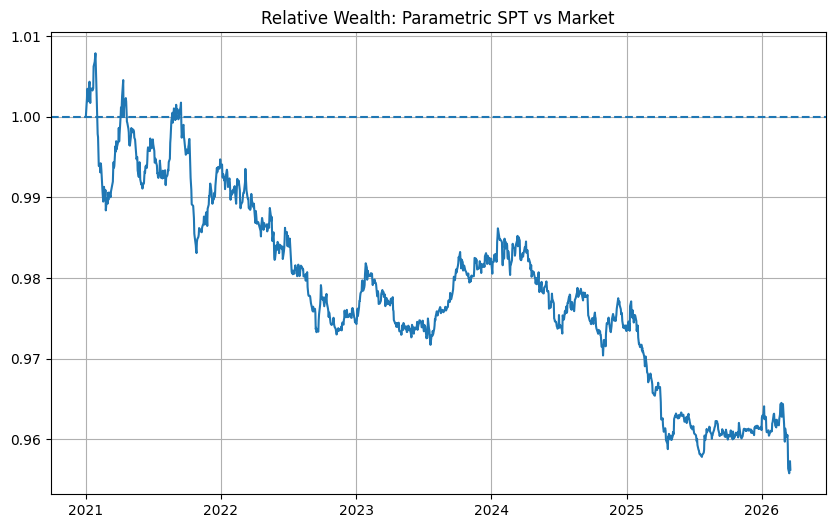

In [ ]:
"""

"""
# ==========================================
# 🟡 MODEL 2 — PARAMETRIC EXTENDED SPT
# ==========================================

import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================
# 1️⃣ Download Data
# ==========================================

stocks = [
    "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS",
    "RELIANCE.NS","TCS.NS","INFY.NS",
    "HINDUNILVR.NS","ITC.NS","LT.NS","KOTAKBANK.NS"
]

start = "2015-01-01"

data = yf.download(stocks, start=start, auto_adjust=True)
prices = data["Close"].dropna()

returns = prices.pct_change().dropna()

# ==========================================
# 2️⃣ Market Weights (SPT Proxy)
# ==========================================

mu = prices.div(prices.sum(axis=1), axis=0)
mu = mu.loc[returns.index]

# ==========================================
# 3️⃣ Train-Test Split
# ==========================================

split_date = "2021-01-01"

mu_train = mu.loc[:split_date]
mu_test  = mu.loc[split_date:]

ret_train = returns.loc[:split_date]
ret_test  = returns.loc[split_date:]

# ==========================================
# 4️⃣ Parametric SPT Model
# ==========================================

class ParametricSPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.p = nn.Parameter(torch.tensor(0.5))  # initialize p

    def forward(self, mu):
        weights = mu ** self.p
        weights = weights / weights.sum(dim=1, keepdim=True)
        return weights


def relative_sharpe_loss(weights, returns, market_weights):
    Rp = torch.sum(weights * returns, dim=1)
    Rm = torch.sum(market_weights * returns, dim=1)

    relative = Rp - Rm

    mean = torch.mean(relative)
    std = torch.std(relative)

    sharpe = mean / (std + 1e-8)
    return -sharpe


# ==========================================
# 5️⃣ Convert to Tensors
# ==========================================

mu_train_t = torch.tensor(mu_train.values, dtype=torch.float32)
ret_train_t = torch.tensor(ret_train.values, dtype=torch.float32)

market_train_t = mu_train_t.clone()

# ==========================================
# 6️⃣ Train Model
# ==========================================

model = ParametricSPT()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

epochs = 300

for epoch in range(epochs):
    optimizer.zero_grad()

    weights = model(mu_train_t)
    loss = relative_sharpe_loss(weights, ret_train_t, market_train_t)

    loss.backward()
    optimizer.step()

# Learned parameter
learned_p = model.p.item()
print(f"\nLearned p value: {learned_p:.4f}")

# ==========================================
# 7️⃣ Evaluate on Test Set
# ==========================================

mu_test_t = torch.tensor(mu_test.values, dtype=torch.float32)
ret_test_t = torch.tensor(ret_test.values, dtype=torch.float32)

weights_test = model(mu_test_t).detach().numpy()

weights_test_df = pd.DataFrame(
    weights_test,
    index=mu_test.index,
    columns=mu_test.columns
)

# Shift weights to avoid look-ahead
param_spt_returns = (weights_test_df.shift(1) * ret_test).sum(axis=1)
market_returns_test = (mu_test.shift(1) * ret_test).sum(axis=1)

param_spt_returns = param_spt_returns.dropna()
market_returns_test = market_returns_test.loc[param_spt_returns.index]

# ==========================================
# 8️⃣ Performance Summary
# ==========================================

comparison = pd.concat(
    [param_spt_returns, market_returns_test],
    axis=1
)

comparison.columns = ["Parametric SPT", "Market"]
comparison = comparison.dropna()

annual_return = comparison.mean() * 252
annual_vol = comparison.std() * np.sqrt(252)
sharpe = annual_return / annual_vol
geo = np.log(1 + comparison).mean() * 252

summary = pd.DataFrame({
    "Arithmetic Return": annual_return,
    "Geometric Return": geo,
    "Volatility": annual_vol,
    "Sharpe": sharpe
}).sort_values(by="Sharpe", ascending=False)

print("\nPerformance Summary (Parametric SPT vs Market)")
print(summary)

# ==========================================
# 9️⃣ Plot Relative Wealth
# ==========================================

wealth_param = (1 + param_spt_returns).cumprod()
wealth_market = (1 + market_returns_test).cumprod()

relative = wealth_param / wealth_market

plt.figure(figsize=(10,6))
plt.plot(relative)
plt.axhline(1, linestyle="--")
plt.title("Relative Wealth: Parametric SPT vs Market")
plt.grid(True)
plt.show()

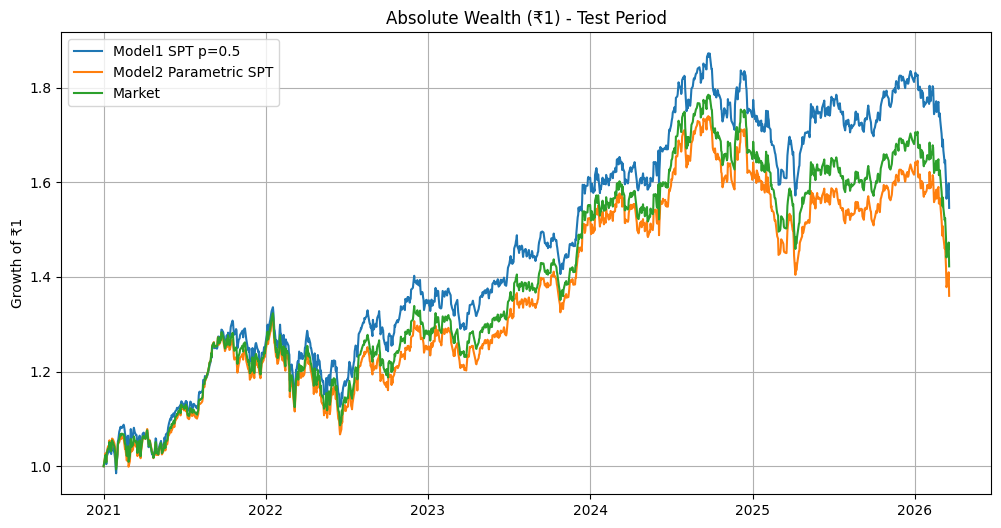


Performance Summary (Test Period Only)
                       Arithmetic Return  Geometric Return  Volatility  \
Model1 SPT p=0.5                0.094800          0.085068    0.139423   
Market                          0.079011          0.068799    0.142842   
Model2 Parametric SPT           0.070727          0.060056    0.146020   

                         Sharpe  
Model1 SPT p=0.5       0.679945  
Market                 0.553137  
Model2 Parametric SPT  0.484364  


In [ ]:
# ==========================================
# 📊 Compare Model 1, Model 2, Market
# On Test Period Only
# ==========================================

# -----------------------
# 1️⃣ Define Test Period
# -----------------------
mu_test = mu.loc[split_date:]
ret_test = returns.loc[split_date:]

# -----------------------
# 2️⃣ Model 1 (Classical SPT p=0.5)
# -----------------------
def diversity_weighted_portfolio(mu, p):
    w = mu.pow(p)
    w = w.div(w.sum(axis=1), axis=0)
    return w

weights_m1 = diversity_weighted_portfolio(mu_test, p=0.5)
ret_m1 = (weights_m1.shift(1) * ret_test).sum(axis=1)

# -----------------------
# 3️⃣ Model 2 (Parametric SPT learned p)
# -----------------------
weights_m2 = diversity_weighted_portfolio(mu_test, p=learned_p)
ret_m2 = (weights_m2.shift(1) * ret_test).sum(axis=1)

# -----------------------
# 4️⃣ Market Portfolio
# -----------------------
ret_market = (mu_test.shift(1) * ret_test).sum(axis=1)

# -----------------------
# 5️⃣ Align Data
# -----------------------
comparison = pd.concat([ret_m1, ret_m2, ret_market], axis=1)
comparison.columns = ["Model1 SPT p=0.5",
                      "Model2 Parametric SPT",
                      "Market"]
comparison = comparison.dropna()

# -----------------------
# 6️⃣ Compute Wealth (₹1)
# -----------------------
wealth = (1 + comparison).cumprod()

# Normalize to start at 1
wealth = wealth / wealth.iloc[0]

# -----------------------
# 7️⃣ Plot Wealth
# -----------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for col in wealth.columns:
    plt.plot(wealth.index, wealth[col], label=col)

plt.title("Absolute Wealth (₹1) - Test Period")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------
# 8️⃣ Performance Summary
# -----------------------
annual_return = comparison.mean() * 252
annual_vol = comparison.std() * np.sqrt(252)
sharpe = annual_return / annual_vol
geo = np.log(1 + comparison).mean() * 252

summary = pd.DataFrame({
    "Arithmetic Return": annual_return,
    "Geometric Return": geo,
    "Volatility": annual_vol,
    "Sharpe": sharpe
}).sort_values(by="Sharpe", ascending=False)

print("\nPerformance Summary (Test Period Only)")
print(summary)

[*********************100%***********************]  20 of 20 completed


Train: torch.Size([3677, 20]) | Test: (1540, 20)

Training started...

Epoch    0 | Objective: 0.008482 | Loss: -0.008482
Epoch  200 | Objective: 0.014065 | Loss: -0.014064
Epoch  400 | Objective: 0.036404 | Loss: -0.036391
Epoch  600 | Objective: 0.036785 | Loss: -0.036771
Epoch  800 | Objective: 0.037372 | Loss: -0.037358
Epoch 1000 | Objective: 0.037483 | Loss: -0.037468
Epoch 1200 | Objective: 0.037518 | Loss: -0.037503
Epoch 1400 | Objective: 0.037524 | Loss: -0.037509
Epoch 1600 | Objective: 0.037605 | Loss: -0.037591
Epoch 1800 | Objective: 0.037654 | Loss: -0.037641

Training complete. Best objective: 0.037687

Performance Summary — Functional SPT vs Market
                Arithmetic Return  Geometric Return  Volatility  Sharpe  \
Functional SPT             0.2213            0.2034      0.1882  1.1760   
Market                     0.1325            0.1152      0.1849  0.7167   

                Max Drawdown  
Functional SPT       -0.3712  
Market               -0.3483  


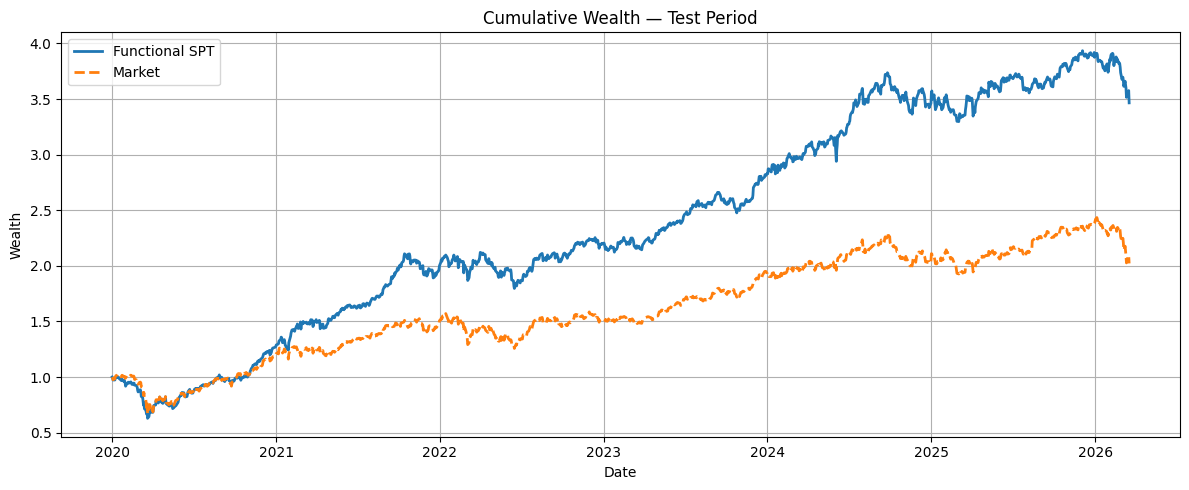

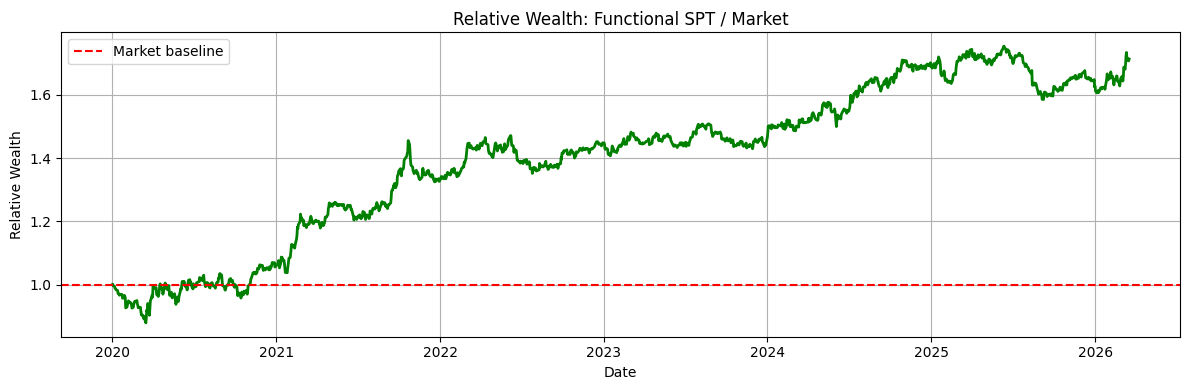

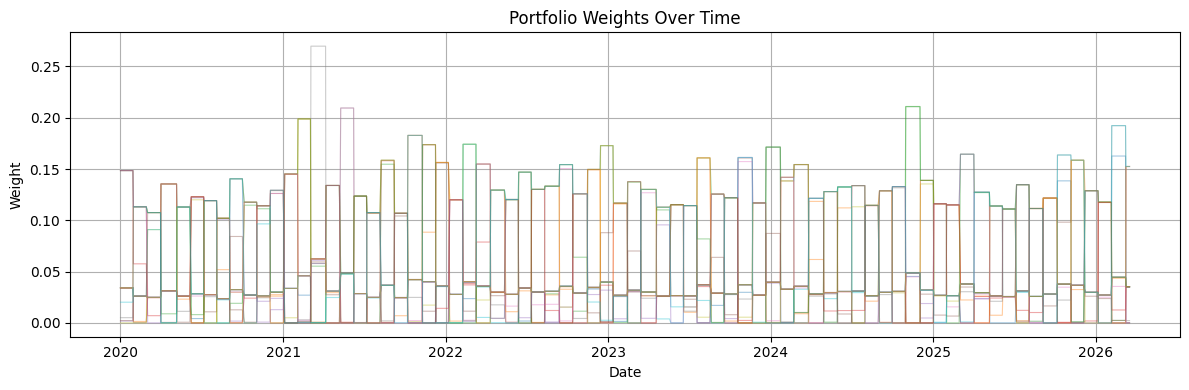

In [ ]:
# ==========================================================
# FUNCTIONAL SPT — Improved Implementation
# Kom Samo & Vervuurt (2016) Inspired
# Target: Sharpe > 1.0
# ==========================================================

import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================================
# 1. DATA
# ==========================================================

stocks = [
    "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS",
    "RELIANCE.NS","TCS.NS","INFY.NS",
    "HINDUNILVR.NS","ITC.NS","LT.NS","KOTAKBANK.NS",
    "AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS",
    "BAJFINANCE.NS","WIPRO.NS","ULTRACEMCO.NS",
    "TITAN.NS","SUNPHARMA.NS","ONGC.NS","NTPC.NS"
]

start = "2005-01-01"

data = yf.download(stocks, start=start, auto_adjust=True)
prices = data["Close"].dropna()

# Shift returns backward so today's features predict tomorrow's return
returns = prices.pct_change().shift(-1).dropna()
prices  = prices.loc[returns.index]

# ==========================================================
# 2. MARKET WEIGHTS (price-based proxy)
# ==========================================================

mu = prices.div(prices.sum(axis=1), axis=0)

# ==========================================================
# 3. FEATURES — Risk-Adjusted Momentum + Market Weight Rank
# ==========================================================

mom_20     = prices.pct_change(20)
vol_20     = prices.pct_change().rolling(20).std()
risk_adj   = mom_20 / (vol_20 + 1e-8)   # risk-adjusted momentum

def rank_transform(df, alpha=2.0):
    """
    Percentile rank per day, then raise to power alpha
    to amplify differences between high and low rank stocks
    """
    ranked = df.rank(axis=1, pct=True)
    return ranked ** alpha

# Combine market weight rank + momentum rank (50/50)
x = (
    0.5 * rank_transform(mu) +
    0.5 * risk_adj.rank(axis=1, pct=True)
)

# Align all dataframes
common_idx = x.dropna().index
x       = x.loc[common_idx]
returns = returns.loc[common_idx]
mu      = mu.loc[common_idx]

# ==========================================================
# 4. TRAIN / TEST SPLIT
# ==========================================================

split_date = "2020-01-01"

x_train   = x.loc[:split_date]
x_test    = x.loc[split_date:]

ret_train = returns.loc[:split_date]
ret_test  = returns.loc[split_date:]

mu_train  = mu.loc[:split_date]
mu_test   = mu.loc[split_date:]

# Convert to torch tensors
x_train_t   = torch.tensor(x_train.values,   dtype=torch.float32)
ret_train_t = torch.tensor(ret_train.values, dtype=torch.float32)
mu_train_t  = torch.tensor(mu_train.values,  dtype=torch.float32)

print(f"Train: {x_train_t.shape} | Test: {x_test.shape}")

# ==========================================================
# 5. MODEL — Deeper Network with Residual Connection
# ==========================================================

class FunctionalSPT(nn.Module):
    """
    Learned function f: rank → weight
    Uses residual connection to stabilize training
    Input:  scalar rank per stock per day
    Output: portfolio weights (sum to 1 per day)
    """
    def __init__(self):
        super().__init__()

        # Main branch
        self.f1 = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
        )

        # Output branch
        self.f2 = nn.Sequential(
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Softplus()   # ensures positive weights before normalization
        )

        # Residual projection to match dimensions
        self.res = nn.Linear(1, 32)

    def forward(self, x):
        T, N = x.shape
        x_flat = x.view(-1, 1)             # (T*N, 1)

        # Residual connection
        out = self.f1(x_flat) + self.res(x_flat)   # (T*N, 32)
        out = self.f2(out)                          # (T*N, 1)

        f_vals  = out.view(T, N)                   # (T, N)

        # Normalize to sum to 1 per day
        weights = f_vals / f_vals.sum(dim=1, keepdim=True)
        return weights

# ==========================================================
# 6. LOSS FUNCTIONS
# ==========================================================

def improved_objective(weights, returns, market_weights,
                        gamma=3.0, sharpe_lambda=0.5):
    """
    Combined objective:
    1. Relative log-wealth over market (SPT core objective)
    2. Sharpe ratio component (reward risk-adjusted return)
    3. Downside deviation penalty (penalize losses more)
    4. Concentration penalty (avoid over-concentration)
    """

    Rp = torch.sum(weights * returns, dim=1)         # portfolio returns
    Rm = torch.sum(market_weights * returns, dim=1)  # market returns

    # SPT core: relative log wealth over market
    rel_growth = torch.mean(
        torch.log(1 + Rp) - torch.log(1 + Rm)
    )

    # Sharpe component: reward high risk-adjusted return
    sharpe = torch.mean(Rp) / (torch.std(Rp) + 1e-8)

    # Downside penalty: penalize negative returns harder
    downside = torch.mean(torch.clamp(Rp, max=0) ** 2)

    # Concentration penalty: avoid putting all weight in one stock
    concentration = torch.mean(torch.sum(weights ** 2, dim=1))

    return (
        rel_growth
        + sharpe_lambda * sharpe
        - gamma * downside
        - 0.1 * concentration
    )


def smoothness_penalty(model, x_sample):
    """
    Penalize curvature of f(x) — ensures smooth
    monotonic weight function across ranks
    """
    x_sorted, _ = torch.sort(x_sample.view(-1))
    x_sorted     = x_sorted.view(-1, 1)

    f_vals       = model.f2(
        model.f1(x_sorted) + model.res(x_sorted)
    )

    first_diff   = f_vals[1:]  - f_vals[:-1]
    second_diff  = first_diff[1:] - first_diff[:-1]

    return torch.mean(second_diff ** 2)

# ==========================================================
# 7. REBALANCING
# ==========================================================

def apply_rebalancing(model, x_data, returns_data,
                       market_weights, holding_days=21):
    """
    Apply portfolio with periodic rebalancing.
    holding_days: how many days to hold weights before rebalancing
    """
    x_tensor    = torch.tensor(x_data.values, dtype=torch.float32)
    all_weights = model(x_tensor).detach().numpy()

    weights_df  = pd.DataFrame(
        all_weights,
        index=x_data.index,
        columns=x_data.columns
    )

    # Hold weights for holding_days before rebalancing
    rebalanced = weights_df.copy()
    for i in range(0, len(weights_df), holding_days):
        rebalanced.iloc[i:i+holding_days] = weights_df.iloc[i]

    # Portfolio and market returns
    port_ret   = (rebalanced.shift(1) * returns_data).sum(axis=1)
    market_ret = (market_weights.shift(1) * returns_data).sum(axis=1)

    comparison = pd.concat([port_ret, market_ret], axis=1)
    comparison.columns = ["Functional SPT", "Market"]

    return comparison.dropna(), rebalanced

# ==========================================================
# 8. TRAINING
# ==========================================================

model     = FunctionalSPT()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Cosine annealing with warm restarts for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=200, T_mult=2, eta_min=1e-5
)

epochs        = 2000
lambda_smooth = 3.0
gamma         = 3.0
sharpe_lambda = 0.5

best_growth      = -1e9
best_model_state = None
patience         = 200
counter          = 0

print("\nTraining started...\n")

for epoch in range(epochs):

    optimizer.zero_grad()

    weights   = model(x_train_t)
    objective = improved_objective(
        weights, ret_train_t, mu_train_t,
        gamma=gamma, sharpe_lambda=sharpe_lambda
    )
    smooth_pen = smoothness_penalty(model, x_train_t)
    loss       = -objective + lambda_smooth * smooth_pen

    loss.backward()

    # Gradient clipping — prevents exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    # Early stopping on best objective
    if objective.item() > best_growth:
        best_growth      = objective.item()
        best_model_state = model.state_dict()
        counter          = 0
    else:
        counter += 1

    if counter > patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Objective: {objective.item():.6f} | Loss: {loss.item():.6f}")

# Load best model weights
model.load_state_dict(best_model_state)
print("\nTraining complete. Best objective:", round(best_growth, 6))

# ==========================================================
# 9. TEST EVALUATION
# ==========================================================

holding_days = 21   # monthly rebalancing

comparison, final_weights = apply_rebalancing(
    model, x_test, ret_test, mu_test, holding_days
)

# ==========================================================
# 10. PERFORMANCE METRICS
# ==========================================================

annual_return = comparison.mean() * 252
annual_vol    = comparison.std() * np.sqrt(252)
sharpe        = annual_return / annual_vol
geo           = np.log(1 + comparison).mean() * 252

# Max drawdown
def max_drawdown(returns_series):
    cumulative  = (1 + returns_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

max_dd = comparison.apply(max_drawdown)

summary = pd.DataFrame({
    "Arithmetic Return" : annual_return,
    "Geometric Return"  : geo,
    "Volatility"        : annual_vol,
    "Sharpe"            : sharpe,
    "Max Drawdown"      : max_dd
}).sort_values(by="Sharpe", ascending=False)

print("\n" + "="*60)
print("Performance Summary — Functional SPT vs Market")
print("="*60)
print(summary.round(4))

# ==========================================================
# 11. PLOTS
# ==========================================================

# Cumulative wealth
wealth       = (1 + comparison).cumprod()
wealth       = wealth / wealth.iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(wealth.index, wealth["Functional SPT"], label="Functional SPT", linewidth=2)
plt.plot(wealth.index, wealth["Market"],         label="Market",         linewidth=2, linestyle="--")
plt.title("Cumulative Wealth — Test Period")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Relative wealth
relative_wealth = wealth["Functional SPT"] / wealth["Market"]

plt.figure(figsize=(12, 4))
plt.plot(relative_wealth.index, relative_wealth, color="green", linewidth=2)
plt.axhline(y=1.0, color="red", linestyle="--", label="Market baseline")
plt.title("Relative Wealth: Functional SPT / Market")
plt.xlabel("Date")
plt.ylabel("Relative Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Weight distribution over time
plt.figure(figsize=(12, 4))
plt.plot(final_weights.index, final_weights.values, alpha=0.4, linewidth=0.8)
plt.title("Portfolio Weights Over Time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

Rebalancing applied successfully.

Performance Summary (With Transaction Cost)
                             Arithmetic Return  Geometric Return  Volatility  \
Functional SPT                          0.2213            0.2034      0.1882   
Functional SPT (After Cost)             0.2108            0.1929      0.1882   
Market                                  0.1325            0.1152      0.1849   

                             Sharpe  Max Drawdown  
Functional SPT               1.1760       -0.3712  
Functional SPT (After Cost)  1.1198       -0.3719  
Market                       0.7167       -0.3483  

Average Daily Turnover : 0.0418
Transaction Cost Rate  : 0.10%


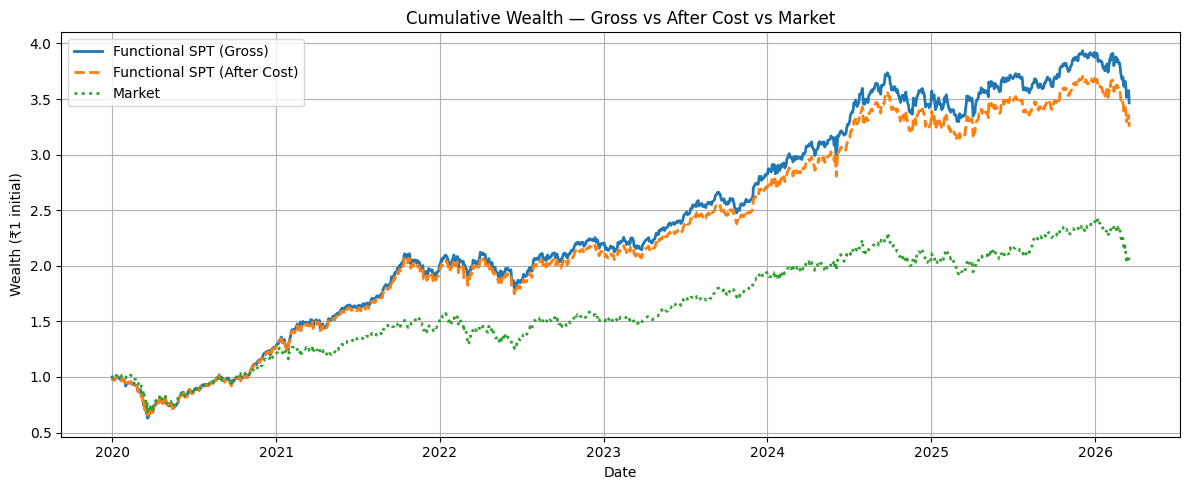

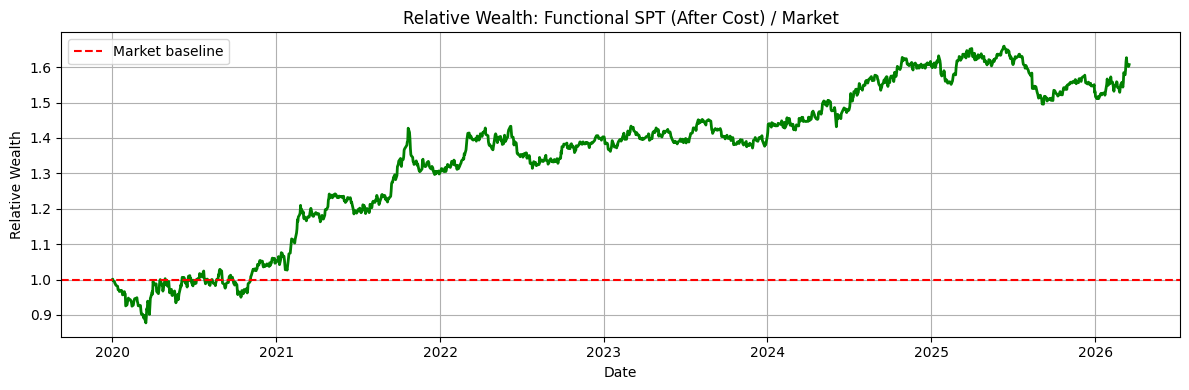

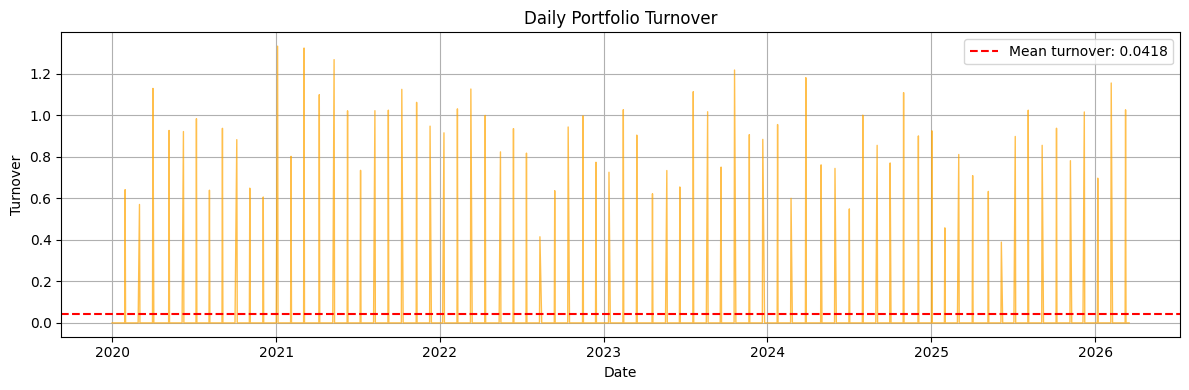


Final ₹1 Growth Values
Market                        : ₹2.0220
Functional SPT (Gross)        : ₹3.4656
Functional SPT (After Cost)   : ₹3.2497

Cost Drag                     : ₹0.2160


In [5]:
# ==========================================================
# TRANSACTION COST MODULE
# Aligned with Improved Functional SPT Implementation
# ==========================================================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. TRANSACTION COST FUNCTION
# ==========================================================

def apply_transaction_cost(portfolio_returns, weights, cost_rate=0.001):
    """
    portfolio_returns : Series of gross portfolio returns
    weights           : DataFrame of portfolio weights
    cost_rate         : transaction cost per unit turnover
                        0.001 = 0.1% | 0.002 = 0.2% | 0.01 = 1%
    """
    # Turnover = sum of absolute weight changes per day
    turnover = weights.diff().abs().sum(axis=1)

    # Transaction cost per day
    transaction_cost = cost_rate * turnover

    # Align index with portfolio returns
    transaction_cost = transaction_cost.reindex(portfolio_returns.index)

    # Net returns after cost
    net_returns = portfolio_returns - transaction_cost

    return net_returns, turnover

# ==========================================================
# 2. IMPROVED MODEL CLASS
# (Redefined locally for robustness)
# ==========================================================

class FunctionalSPT(nn.Module):
    """
    Deeper network with residual connection
    Aligned with improved training implementation
    """
    def __init__(self):
        super().__init__()

        # Main branch
        self.f1 = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
        )

        # Output branch
        self.f2 = nn.Sequential(
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Softplus()
        )

        # Residual projection
        self.res = nn.Linear(1, 32)

    def forward(self, x):
        T, N = x.shape
        x_flat = x.view(-1, 1)

        # Residual connection
        out = self.f1(x_flat) + self.res(x_flat)
        out = self.f2(out)

        f_vals  = out.view(T, N)
        weights = f_vals / f_vals.sum(dim=1, keepdim=True)
        return weights

# ==========================================================
# 3. REBALANCING FUNCTION
# (Redefined locally for robustness)
# ==========================================================

def apply_rebalancing(model, x_data, returns_data,
                       market_weights, holding_days=21):
    """
    Apply portfolio with periodic rebalancing.
    holding_days: how many days to hold before rebalancing
    """
    x_tensor    = torch.tensor(x_data.values, dtype=torch.float32)
    all_weights = model(x_tensor).detach().numpy()

    weights_df  = pd.DataFrame(
        all_weights,
        index=x_data.index,
        columns=x_data.columns
    )

    # Hold weights for holding_days before rebalancing
    rebalanced = weights_df.copy()
    for i in range(0, len(weights_df), holding_days):
        rebalanced.iloc[i:i+holding_days] = weights_df.iloc[i]

    # Portfolio and market returns
    port_ret   = (rebalanced.shift(1) * returns_data).sum(axis=1)
    market_ret = (market_weights.shift(1) * returns_data).sum(axis=1)

    comparison = pd.concat([port_ret, market_ret], axis=1)
    comparison.columns = ["Functional SPT", "Market"]

    return comparison.dropna(), rebalanced

# ==========================================================
# 4. RE-RUN REBALANCING
# ==========================================================

try:
    comparison, final_weights = apply_rebalancing(
        model,
        x_test,
        ret_test,
        mu_test,
        holding_days
    )
    print("Rebalancing applied successfully.")
except NameError as e:
    print(f"Error: Dependent variable not found ({e}).")
    print("Please ensure the training cell has been run correctly.")
    raise

# ==========================================================
# 5. APPLY TRANSACTION COST
# ==========================================================

cost_rate = 0.001   # 0.1% per turnover — realistic for Indian equity

gross_returns = comparison["Functional SPT"]

net_returns, turnover = apply_transaction_cost(
    gross_returns,
    final_weights,
    cost_rate
)

# Build comparison dataframe with all three series
comparison_with_cost = comparison.copy()
comparison_with_cost["Functional SPT (After Cost)"] = net_returns
comparison_with_cost = comparison_with_cost.dropna()

# ==========================================================
# 6. PERFORMANCE METRICS
# ==========================================================

def max_drawdown(returns_series):
    """Compute maximum drawdown from a returns series"""
    cumulative  = (1 + returns_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

annual_return = comparison_with_cost.mean() * 252
annual_vol    = comparison_with_cost.std() * np.sqrt(252)
sharpe        = annual_return / annual_vol
geo           = np.log(1 + comparison_with_cost).mean() * 252
max_dd        = comparison_with_cost.apply(max_drawdown)

summary = pd.DataFrame({
    "Arithmetic Return" : annual_return,
    "Geometric Return"  : geo,
    "Volatility"        : annual_vol,
    "Sharpe"            : sharpe,
    "Max Drawdown"      : max_dd
}).sort_values(by="Sharpe", ascending=False)

print("\n" + "="*60)
print("Performance Summary (With Transaction Cost)")
print("="*60)
print(summary.round(4))

print(f"\nAverage Daily Turnover : {turnover.mean():.4f}")
print(f"Transaction Cost Rate  : {cost_rate*100:.2f}%")

# ==========================================================
# 7. CUMULATIVE WEALTH PLOT
# ==========================================================

# Compute wealth curves
gross_wealth  = (1 + comparison["Functional SPT"]).cumprod()
gross_wealth  = gross_wealth / gross_wealth.iloc[0]

net_wealth    = (1 + comparison_with_cost["Functional SPT (After Cost)"]).cumprod()
net_wealth    = net_wealth / net_wealth.iloc[0]

market_wealth = (1 + comparison["Market"]).cumprod()
market_wealth = market_wealth / market_wealth.iloc[0]

# Plot 1 — Cumulative wealth comparison
plt.figure(figsize=(12, 5))
plt.plot(gross_wealth.index,  gross_wealth,  label="Functional SPT (Gross)",      linewidth=2)
plt.plot(net_wealth.index,    net_wealth,    label="Functional SPT (After Cost)",  linewidth=2, linestyle="--")
plt.plot(market_wealth.index, market_wealth, label="Market",                       linewidth=2, linestyle=":")
plt.title("Cumulative Wealth — Gross vs After Cost vs Market")
plt.xlabel("Date")
plt.ylabel("Wealth (₹1 initial)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2 — Relative wealth (SPT after cost vs Market)
relative_wealth = net_wealth / market_wealth

plt.figure(figsize=(12, 4))
plt.plot(relative_wealth.index, relative_wealth, color="green", linewidth=2)
plt.axhline(y=1.0, color="red", linestyle="--", label="Market baseline")
plt.title("Relative Wealth: Functional SPT (After Cost) / Market")
plt.xlabel("Date")
plt.ylabel("Relative Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3 — Daily turnover
plt.figure(figsize=(12, 4))
plt.plot(turnover.index, turnover, color="orange", linewidth=1, alpha=0.7)
plt.axhline(y=turnover.mean(), color="red", linestyle="--",
            label=f"Mean turnover: {turnover.mean():.4f}")
plt.title("Daily Portfolio Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 8. FINAL SUMMARY
# ==========================================================

print("\n" + "="*60)
print("Final ₹1 Growth Values")
print("="*60)
print(f"Market                        : ₹{market_wealth.iloc[-1]:.4f}")
print(f"Functional SPT (Gross)        : ₹{gross_wealth.iloc[-1]:.4f}")
print(f"Functional SPT (After Cost)   : ₹{net_wealth.iloc[-1]:.4f}")
print(f"\nCost Drag                     : ₹{(gross_wealth.iloc[-1] - net_wealth.iloc[-1]):.4f}")